In [1]:
import sys, os
from utils import * 


In [2]:
import joblib

DATASET_NAME, X_train, X_test, y_train, y_test = joblib.load("IEEE_data.pkl")
y_test = y_test.values.ravel()

MODEL_NAME = "Isolation_Forest"
DE_LONG_RESULTS = "IEEE_CIS_all_results.pkl"
METRICS = "IEEE_CIS_metrics.pkl"


In [3]:
# ===============================================================
# ===============================================================
# ===============================================================
# ===============================================================
# ===============================================================
# ===================== 2. Isolation Forest =====================
# ===============================================================
# ===============================================================
# ===============================================================
# ===============================================================
# ===============================================================

In [4]:
# ===================== Fit Isolation Forest =====================
iso_train_scores, iso_test_scores, iso_model = run_isolation_forest(X_train, X_test)


In [11]:
# ===================== Store metrics =====================
iso_metrics = store_anomaly_metrics(y_true=y_test, scores=-iso_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)
display(isolation_forest_metrics)


,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,Isolation_Forest,train_transaction22,0.089401,0.082-0.096,0.127752,0.118-0.138,0.10519,0.097-0.113,0.614814,0.606-0.623,0.059595,0.056-0.063,"[[108597, 5378], [3605, 528]]",0.081331


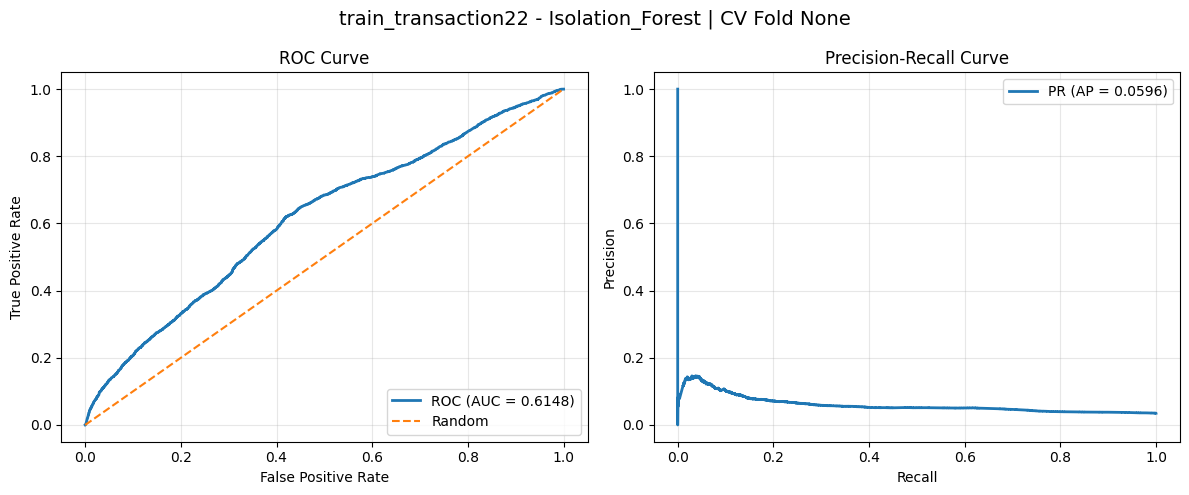

In [18]:
# ===================== Plot results =====================
plot_anomaly_roc_pr(y_true=y_test, scores=-iso_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)


In [8]:
# ===================== Fit on CV folds =====================

iso_cv_results = fit_cross_validate(X_train, y_train, X_test, y_test, run_isolation_forest, DATASET_NAME, MODEL_NAME, CV_FOLDS, RANDOM_STATE)


In [9]:
# ===================== Store CV metrics =====================

iso_cv_metrics = pd.concat([r["test_metrics"] for r in iso_cv_results], ignore_index=True)
display(iso_cv_metrics)


,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,Isolation_Forest_Fold1,train_transaction22,0.020657,0.017-0.024,0.029519,0.025-0.034,0.024305,0.020-0.028,0.375356,0.367-0.384,0.026516,0.026-0.028,"[[108191, 5784], [4011, 122]]",0.104900
1,Isolation_Forest_Fold2,train_transaction22,0.019409,0.016-0.023,0.027825,0.023-0.033,0.022867,0.019-0.027,0.379719,0.371-0.389,0.026449,0.025-0.027,"[[108165, 5810], [4018, 115]]",0.097746
2,Isolation_Forest_Fold3,train_transaction22,0.020819,0.017-0.024,0.029760,0.025-0.035,0.024500,0.020-0.029,0.381303,0.373-0.390,0.026763,0.026-0.028,"[[108190, 5785], [4010, 123]]",0.098856
3,Isolation_Forest_Fold4,train_transaction22,0.019804,0.016-0.023,0.028309,0.023-0.033,0.023304,0.019-0.027,0.386053,0.378-0.395,0.026648,0.026-0.028,"[[108184, 5791], [4016, 117]]",0.097759
4,Isolation_Forest_Fold5,train_transaction22,0.020777,0.017-0.024,0.029760,0.025-0.035,0.024470,0.020-0.029,0.385698,0.377-0.395,0.026869,0.026-0.028,"[[108178, 5797], [4010, 123]]",0.099372


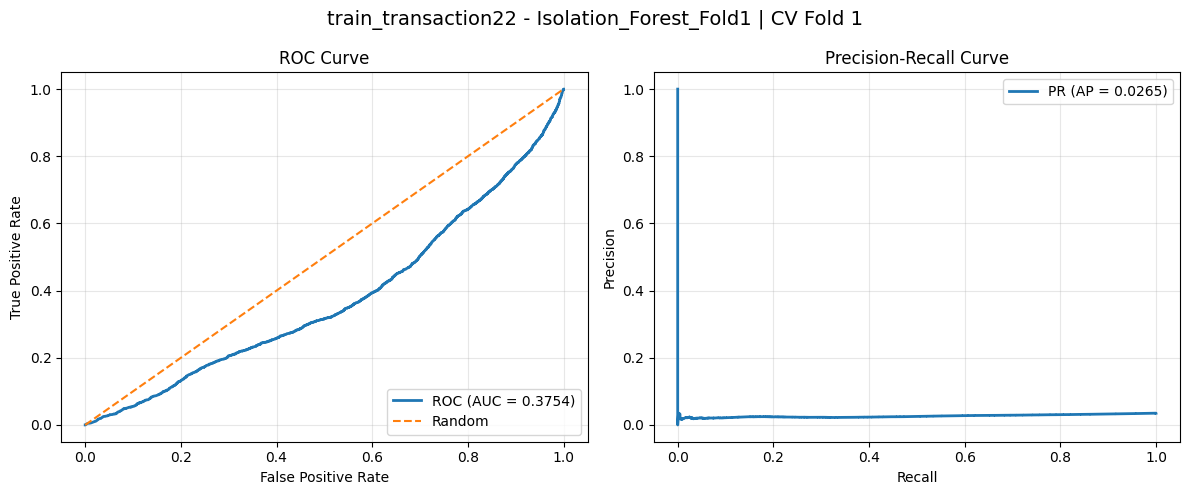

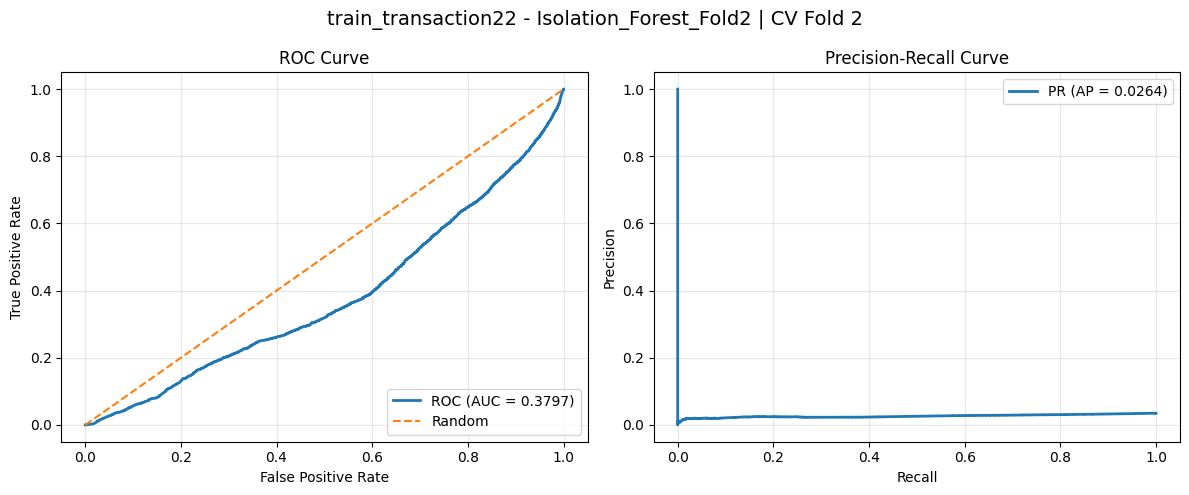

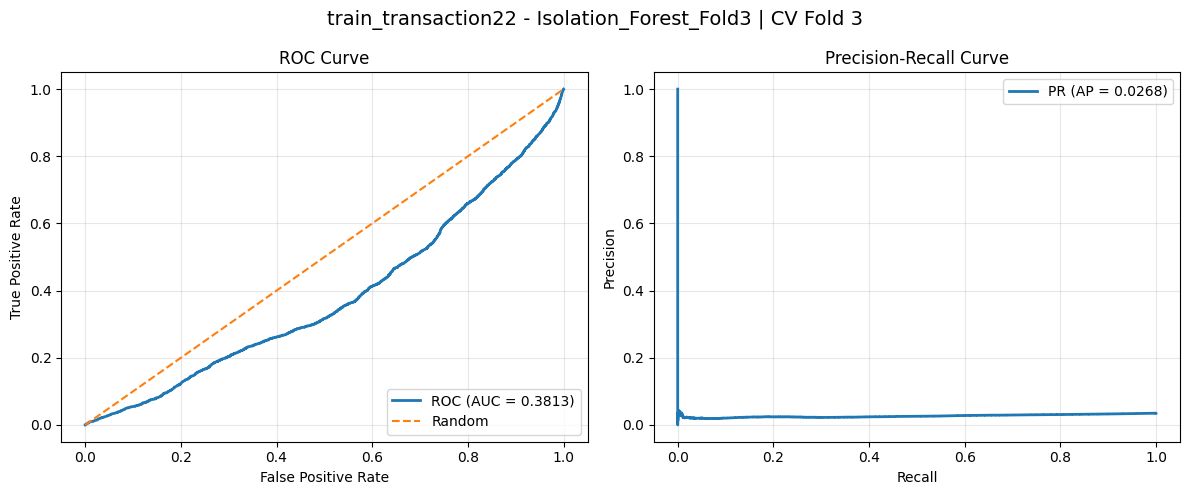

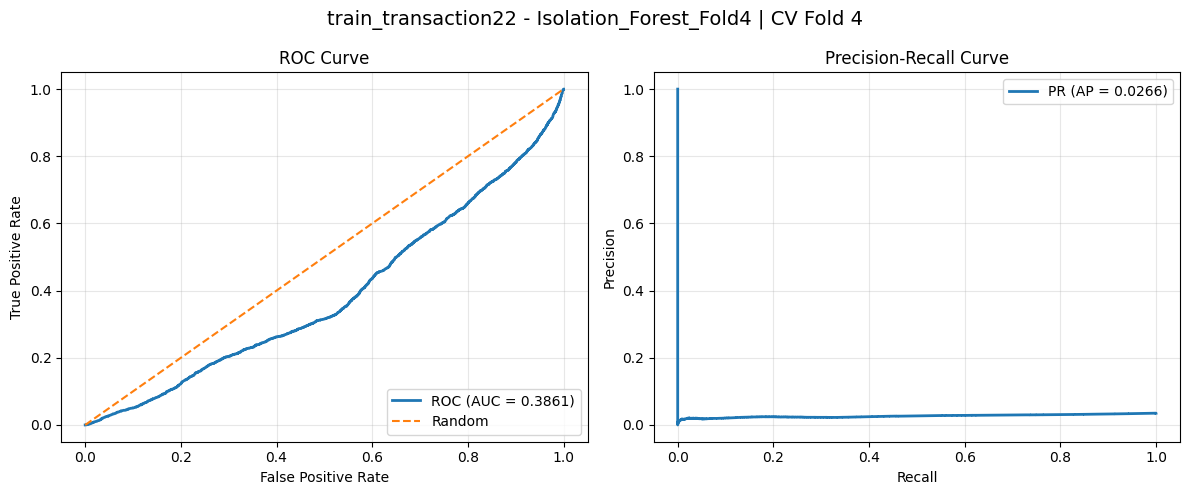

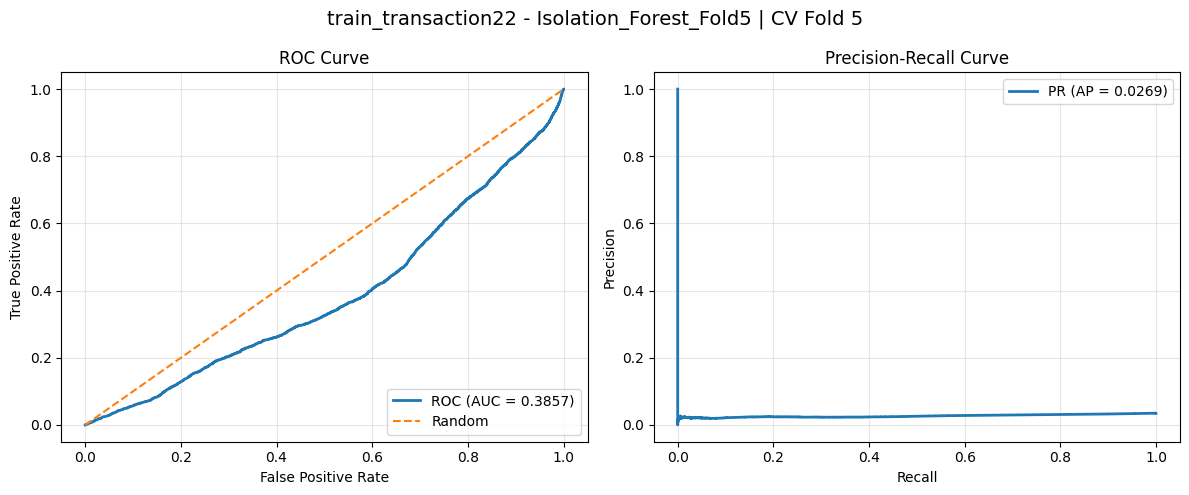

In [10]:
# ===================== Plot CV results =====================

for r in iso_cv_results:
    plot_anomaly_roc_pr(y_test, r["test_scores"], DATASET_NAME, f"{MODEL_NAME}_Fold{r['fold']}", r["fold"])


In [19]:
if os.path.exists(DE_LONG_RESULTS):
    results = joblib.load(DE_LONG_RESULTS)
else:
    results = {}

results[MODEL_NAME] = {
    "test_scores": -iso_test_scores,
    "auc": roc_auc_score(y_test, -iso_test_scores)
}

joblib.dump(results, DE_LONG_RESULTS)

['IEEE_CIS_all_results.pkl']

In [16]:
if os.path.exists(METRICS):
    results = joblib.load(METRICS)
else:
    results = {}

results[MODEL_NAME] = {
    "metrics": iso_metrics,
    "cv_metrics": iso_cv_results
}

joblib.dump(results, METRICS)

['IEEE_CIS_metrics.pkl']